
# ERT field data with Topography

using Tom's data. Only one in the raw data file so using his only other 3 .dat files to sort thru and determine what's good... removed the topography at the end of each file. 

First adding our imports.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert
import os


Now call the data file and load it.

In [2]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line02", exist_ok=True)
os.makedirs(r"pygimex/ert/extra_files/line02", exist_ok=True)

filename = r'data\line02\Line02_DD-Grad_B_notopo.dat'
data = ert.load(filename)
print(data)

26/02/26 - 17:45:14 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 2947, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


Topography loading time!!! I am using my relative topography that I created in excel. It will be plotting elevation versus interpolated electrode position.

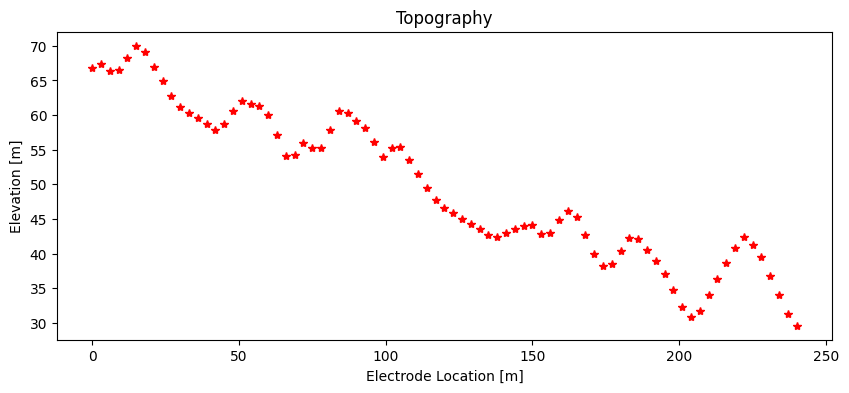

In [3]:
topo = []

topo_file = r'data/line02/line02_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so agradient to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

x_elec = pg.x(data)  # get x pos of all electrodes

z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# print(f'x_elec: {x_elec}')

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))


# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# print(f'z_interp: {z_interp}')

# set electrode positions in data

data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# plot to check
fig, ax = plt.subplots(figsize=(10,4)) 
ax.plot(x_elec, z_interp, 'r*')
ax.set_xlabel('Electrode Location [m]')
ax.set_ylabel('Elevation [m]')
ax.set_title('Topography')

fig.savefig(r"figures/line02/topography_gradient.png", dpi=300, bbox_inches='tight') 
plt.show()

from chat: "K converts measured resistance to apparent resistivity.
- Analytical: assumes flat ground and ideal geometry, so less accurate.
- Numerical: solves with PDE and uses real electrode positions and topography."

This file has resistance (hence the 1).

In [4]:
# topo= pg.PosVector(topo)  # turn from array into pygimli pos vector

k0 = ert.createGeometricFactors(data)  # analytical; assumes simple geometry
data['k'] = ert.createGeometricFactors(data, numerical=True)  # numerical; solves forward PDE

26/02/26 - 17:45:19 - pyGIMLi - INFO - Save RVector binary
26/02/26 - 17:45:19 - pyGIMLi - INFO - Cache stored: C:\Users\sydne\AppData\Roaming\pygimli\Cache\13464864116022625871
26/02/26 - 17:45:19 - pyGIMLi - INFO - Create default mesh for geometric factor calculation.


26/02/26 - 17:45:25 - pyGIMLi - INFO - Save RVector binary
26/02/26 - 17:45:25 - pyGIMLi - INFO - Cache stored: C:\Users\sydne\AppData\Roaming\pygimli\Cache\15679998880613470738


Now we shall observe the topography effect, i.e the ratio between
the numerically computed geometry factor and the analytical formula after
Rücker et al. (2006). We display it using a colormap with neutral white.

from chat: "Topographic effect on resistivity
- ~1: topo has little effect
- topo > 1: ignoring topo overestimates resistivity
- topo < 1: ignoring topo underestimates resistivity"

bwr colormap directory:
- blue: high numerical k
- red: high analytical k
- white: same

Pseudo-depth: sensitivity location.
- gradient: dipole dipole.
- Numbers: electrode spacing levels. 
    - Current: controls how deep the current penetrates (A-B)
    - Potential: controls voltage sensitivity (M-N).
- ex. gradient2-3:
    - current dipole spacing: 2 electrodes.
    - potential dipole spacing: 3 electrodes. 

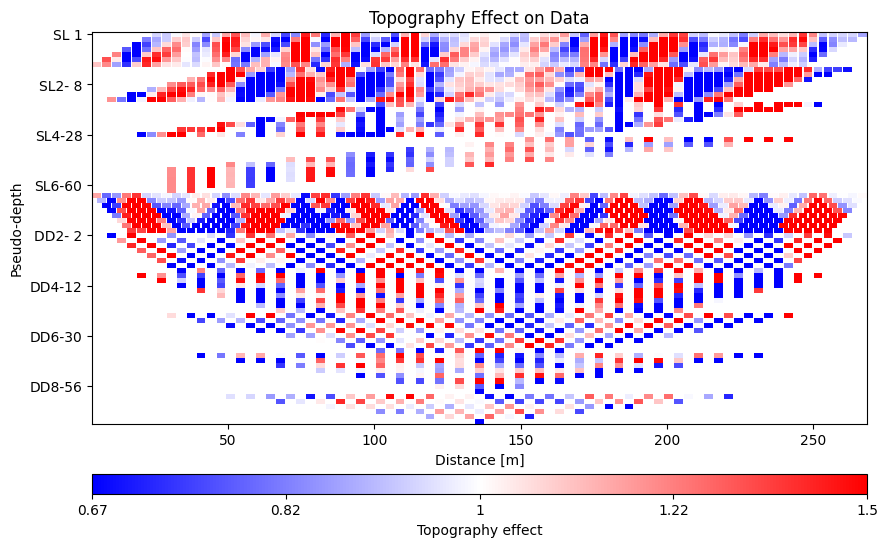

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
_ = ert.showData(data, 
                 vals=k0/ data['k'],  # quantifies the topography effect
                 ax=ax,
                 label='Topography effect', xlabel='Distance [m]', ylabel='Pseudo-depth',
                 cMin=2/3, cMax=3/2,  # color limits
                 logScale=True, 
                 cMap="bwr"  # blue-white-red colormap
)

ax.set_title('Topography Effect on Data');

fig.savefig(r"figures/line02/topo_effect_on_data_DDgradient.png", dpi=300, bbox_inches='tight')


If the topography effect on data looks strange (ie. no color bar, axes titles) just rerun and it'll work!!!


We can now compute the apparent resistivity and display it, once with the
wrong analytical formula and once with the numerical values.



 Min: 20.878086371024185, Max: 8712.431917605578


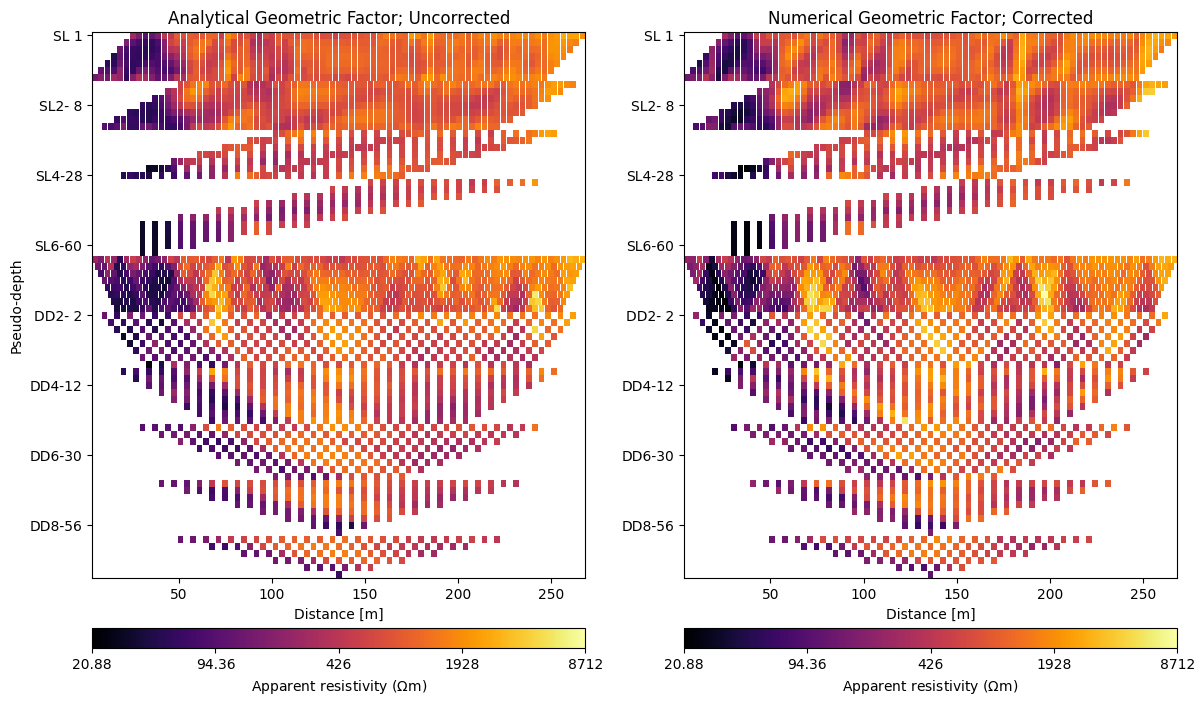

In [7]:
data['rhoa'] = data['r'] * data['k']  # uses numerical k; converts measured resistances to apparent resist

# edit impossible negative or zero values
data['rhoa'][data['rhoa'] <= 0] = 1e-6

cmin = pg.min(data['rhoa'])
cmax = pg.max(data['rhoa'])
print(f' Min: {pg.min(data["rhoa"])}, Max: {pg.max(data["rhoa"])}')

kw = dict(cMin=cmin, cMax=cmax)  # storing key/value pairs for colour scale
fig, ax = plt.subplots(ncols=2, figsize=(14, 8))

data.show(data['r']*k0, ax=ax[0], **kw, cMap='inferno', 
          xlabel='Distance [m]', ylabel='Pseudo-depth');  # uses analytical k so assumes flat ground

data.show(ax=ax[1], **kw, cMap='inferno',
          xlabel='Distance [m]')  # uses numerical k so agradients topo

ax[0].set_title('Analytical Geometric Factor; Uncorrected')  # analytical
ax[1].set_title('Numerical Geometric Factor; Corrected');  # numerical 

fig.savefig(r"figures/line02/uncorrected_vs_corrected_geometric_DDgradient.png", dpi=300, bbox_inches='tight')


Now we shall do a data error estimate!

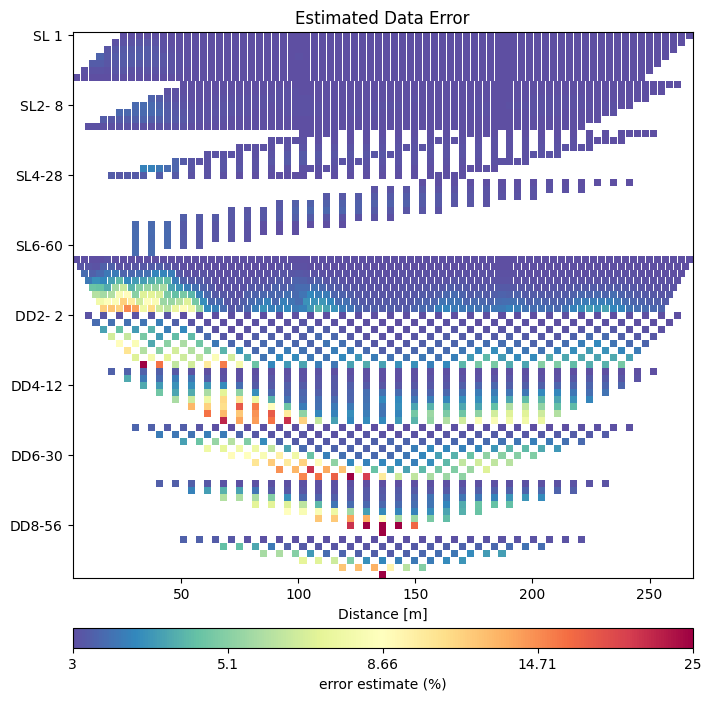

In [10]:
data.estimateError(relativeError=0.03, absoluteUError=5e-5)

fig, ax = plt.subplots(figsize=(8,8))
_ = data.show( data['err']*100, ax=ax,
    label='error estimate (%)', xlabel='Distance [m]',
    cMin=3, cMax=25)

ax.set_title('Estimated Data Error');

fig.savefig(r"figures/line02/est_data_error_DDgradient.png", dpi=300, bbox_inches='tight')


We initialize the ERTManager for further steps and eventually inversion.



In [11]:
mgr = ert.ERTManager(data)

Now the data have all necessary fields ('rhoa', 'err' and 'k') so we can run
the inversion!!!




26/02/26 - 17:46:10 - pyGIMLi - INFO - Found 2 regions.
26/02/26 - 17:46:10 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/02/26 - 17:46:10 - pyGIMLi - INFO - Found 2 regions.
26/02/26 - 17:46:10 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
26/02/26 - 17:46:10 - pyGIMLi - INFO - Creating forward mesh from region infos.


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas\pygimex\ert\extra_files\line02


26/02/26 - 17:46:10 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
26/02/26 - 17:46:10 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10094 Cells: 19596 Boundaries: 14992
26/02/26 - 17:46:10 - pyGIMLi - INFO - Use median(data values)=695.7174158828966
26/02/26 - 17:46:10 - pyGIMLi - INFO - Created startmodel from forward operator:3771, min/max=695.717416/695.717416
26/02/26 - 17:46:10 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000017FBA5AEE80>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 20.88/8712
min/max (error): 3%/58.26%
min/max (start model): 696/696
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  841.97
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  372.16 (dPhi = 55.61%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  102.87 (dPhi = 71.52%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   53.88 (dPhi = 46.97%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =   17.89 (dPhi = 62.36%) lam: 10.0
--------------------------------------------------

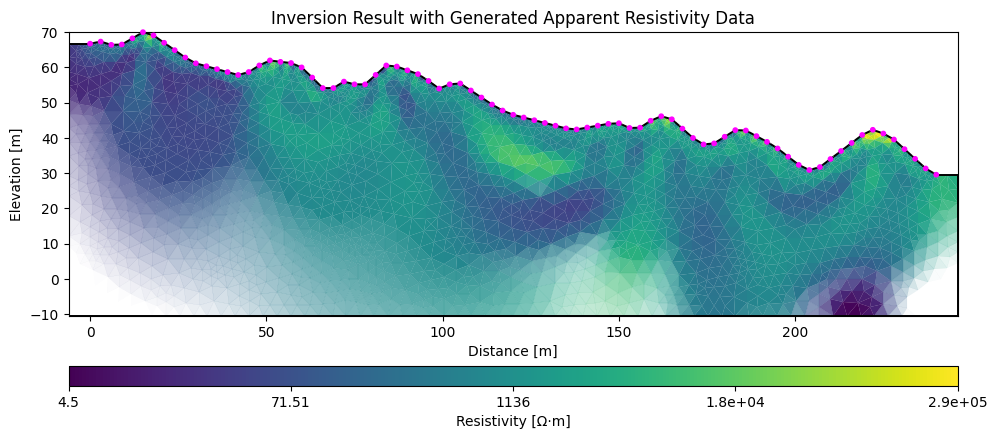

In [12]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas\pygimex\ert\extra_files\line02')
print(f'Directory: {os.getcwd()}')

mod = mgr.invert(data, lam=10, verbose=True,
                 paraDX=0.3, paraMaxCellSize=10, paraDepth=40, quality=33.6)

os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')

fig, ax = plt.subplots(figsize=(10, 8))
ax, cb = mgr.showResult(ax=ax, cMap = 'viridis')
cb.set_label("Resistivity [Ω·m]") 

ax.set_title("Inversion Result with Generated Apparent Resistivity Data")
ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")

fig.savefig(r"figures\line02\inversion_result_DDgradient.png", dpi=300, bbox_inches="tight")

Now we can view with data response rms X^2 fun stuff...


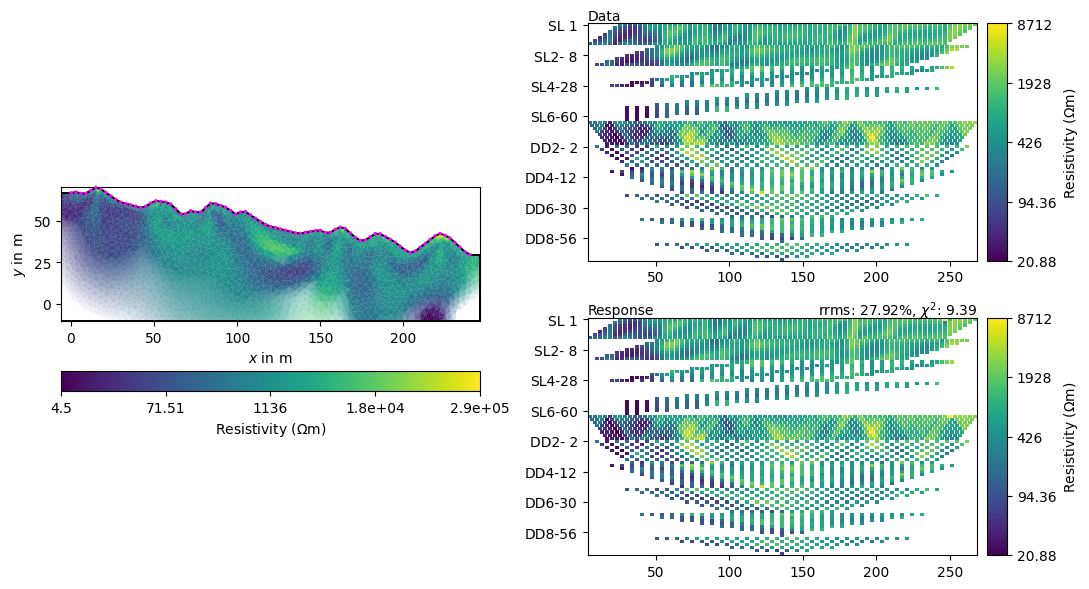

In [13]:
ax = mgr.showResultAndFit(cMap = 'viridis')
fig = ax.figure

fig.savefig(r"figures\line02\inver_data_response_DDgradient.png",dpi=300,bbox_inches="tight")

Now we're gonna constrain the resistivities a teeny tiny bit.....

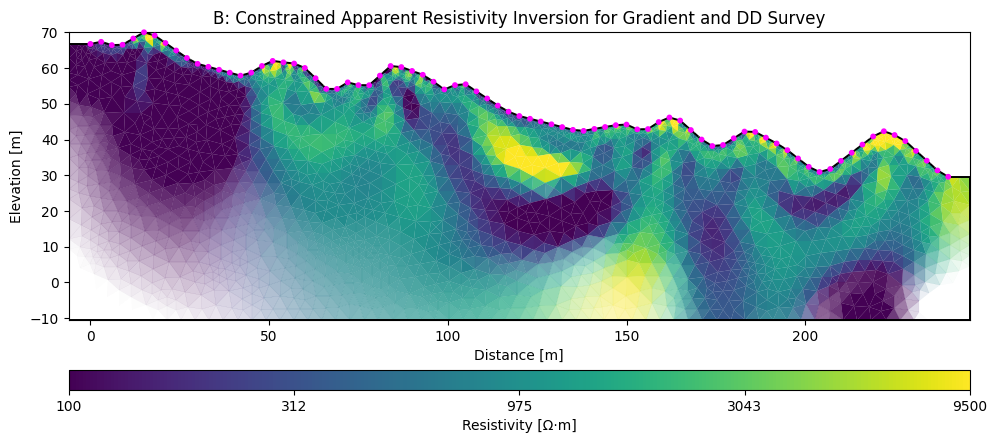

In [20]:
fig, ax = plt.subplots(figsize=(10,8))
ax, cb = mgr.showResult(mod, ax=ax, cMin=100, cMax=9500, cMap='viridis',logScale=True)

cb.set_label("Resistivity [Ω·m]") 

ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")
ax.set_title('B: Constrained Apparent Resistivity Inversion for Gradient and DD Survey')

fig.savefig(r"figures/line02/constr_inver_DDgradientB.png", dpi=300, bbox_inches='tight')